In [1]:
!pip install torch torchvision torchaudio
!pip install scipy

# Prepare data

In [2]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset

print("正在加载 SVHN cropped 数据集...")

# ==================== 数据预处理 ====================
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
)

# ==================== 加载数据集 ====================
root_path = "./svhn_cropped"  

train_set = torchvision.datasets.SVHN(
    root=root_path, split="train", download=False, transform=transform
)

test_set = torchvision.datasets.SVHN(
    root=root_path, split="test", download=False, transform=transform
)

# 加 extra（53万张免费数据，强烈建议！）
extra_set = torchvision.datasets.SVHN(
    root=root_path, split="extra", download=False, transform=transform
)

full_train_set = ConcatDataset([train_set, extra_set])

# ==================== DataLoader ====================
train_loader = DataLoader(
    full_train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True
)

test_loader = DataLoader(
    test_set, batch_size=128, shuffle=False, num_workers=4, pin_memory=True
)

print(f"加载完成！")
print(f"训练集大小: {len(full_train_set):,} 张 (train + extra)")
print(f"测试集大小: {len(test_set):,} 张")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


正在加载 SVHN cropped 数据集...
加载完成！
训练集大小: 604,388 张 (train + extra)
测试集大小: 26,032 张


# Model 1

## Model 1: Baseline MLP

**Architecture:**
* two layers: 
  * l1: 512units
  * l2: 10 units
* Activation Function
  * A1 -> Rulu

In [3]:
# !pip install matplotlib
# !pip install tqdm
# !pip3 install pandas

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm  


# ==================== Baseline MLP ====================
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() # 将输入从 (C, H, W) 展平为 (C*H*W)—> Vectorization
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


# ==================== 设备 + 实例化 ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = BaselineMLP().to(device)
print(f"Model 1 使用设备: {device}")

Model 1 使用设备: cuda


## Model 1: Training + Record(epoch: 15)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

# 记录容器
train_loss_list = []
train_acc_list = []  # Added for train accuracy
test_acc_list = []
epochs = 15

print("开始训练 Model 1 Baseline MLP...")

for epoch in range(epochs):
    # ---------- Train ----------
    model1.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    
    train_loss_list.append(avg_train_loss)
    train_acc_list.append(train_acc)  # Store train accuracy

    # ---------- Test ----------
    model1.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model1(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%"
    )

print(" Trainning Model 1 Successly！")

开始训练 Model 1 Baseline MLP...


Epoch 1/15: 100%|██████████| 4722/4722 [00:54<00:00, 86.11it/s]


Epoch  1 | Train Loss: 0.5332 | Train Acc: 84.71% | Test Acc: 81.38%


Epoch 2/15: 100%|██████████| 4722/4722 [00:55<00:00, 84.80it/s]


Epoch  2 | Train Loss: 0.3776 | Train Acc: 89.69% | Test Acc: 83.00%


...

Epoch 13 | Train Loss: 0.2707 | Train Acc: 92.77% | Test Acc: 85.88%


Epoch 14/15: 100%|██████████| 4722/4722 [00:55<00:00, 85.08it/s]


Epoch 14 | Train Loss: 0.2675 | Train Acc: 92.86% | Test Acc: 86.32%


Epoch 15/15: 100%|██████████| 4722/4722 [00:54<00:00, 86.14it/s]


Epoch 15 | Train Loss: 0.2647 | Train Acc: 92.97% | Test Acc: 86.45%
 Trainning Model 1 Successly！


## Model 1: Visualization

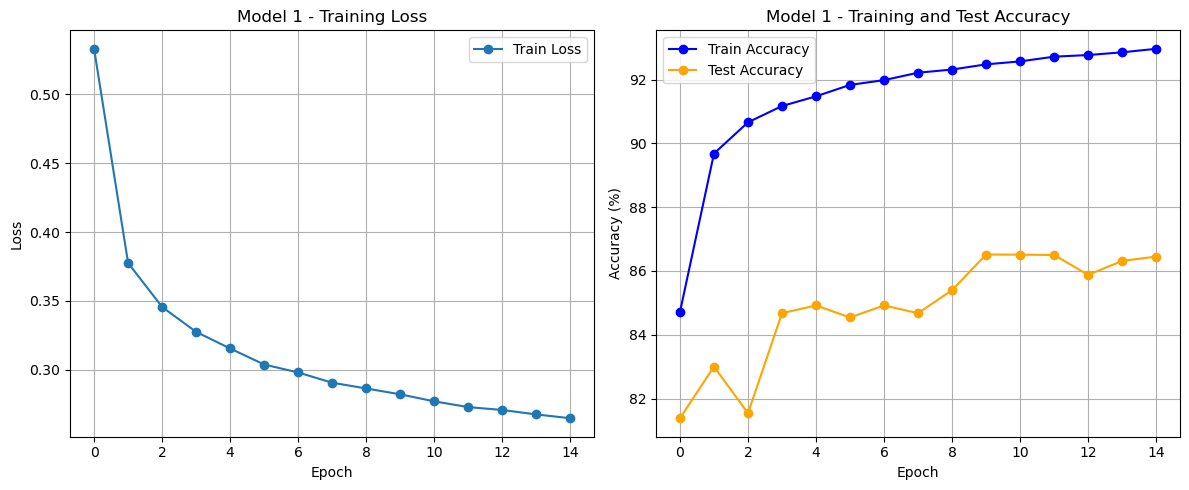

,Model,Epochs,Final Train Accuracy,Final Test Accuracy,Final Train Loss,comment
0,Baseline MLP,15,92.97%,86.45%,0.2647,simple two layers MLP（baseline）


In [6]:
# ==================== 画曲线 ====================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label="Train Loss", marker="o")
plt.title("Model 1 - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label="Train Accuracy", color="blue", marker="o")
plt.plot(test_acc_list, label="Test Accuracy", color="orange", marker="o")
plt.title("Model 1 - Training and Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ==================== 最终结果表格 ====================
import pandas as pd

results = pd.DataFrame(
    {
        "Model": ["Baseline MLP"],
        "Epochs": [epochs],
        "Final Train Accuracy": [f"{train_acc_list[-1]:.2f}%"],  # Added train accuracy
        "Final Test Accuracy": [f"{test_acc_list[-1]:.2f}%"],
        "Final Train Loss": [f"{train_loss_list[-1]:.4f}"],
        "comment": ["simple two layers MLP（baseline）"],
    }
)
display(results)

# Model 2

## Model 2: Defination

In [7]:
import torch.nn as nn

class ImprovedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 1024),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model2 = ImprovedMLP().to(device)
print(f"Model 2 Improved MLP create the number of parameters: {sum(p.numel() for p in model2.parameters()):,}")

Model 2 Improved MLP create the number of parameters: 3,805,450


## Model 2: Train(epoch:15)

In [8]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

train_loss_list2 = []
train_acc_list2 = []  # Added for train accuracy
test_acc_list2 = []
epochs = 15

print("开始训练 Model 2 Improved MLP...")

for epoch in range(epochs):
    # Train
    model2.train()
    running_loss = 0.0
    correct_train = 0  # Added
    total_train = 0    # Added
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train  # Added
    
    train_loss_list2.append(avg_train_loss)
    train_acc_list2.append(train_acc)  # Store train accuracy
    
    # Test
    model2.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_acc = 100 * correct / total
    test_acc_list2.append(test_acc)
    
    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")  # Updated print

print("Model 2 训练完成！")

开始训练 Model 2 Improved MLP...


Epoch 1/15: 100%|██████████| 4722/4722 [00:55<00:00, 85.57it/s]


Epoch  1 | Train Loss: 0.9437 | Train Acc: 70.73% | Test Acc: 75.94%


Epoch 2/15: 100%|██████████| 4722/4722 [00:54<00:00, 86.03it/s]


Epoch  2 | Train Loss: 0.7164 | Train Acc: 78.95% | Test Acc: 79.33%


...

Epoch 13 | Train Loss: 0.5103 | Train Acc: 85.54% | Test Acc: 83.46%


Epoch 14/15: 100%|██████████| 4722/4722 [00:54<00:00, 86.08it/s]


Epoch 14 | Train Loss: 0.5039 | Train Acc: 85.75% | Test Acc: 84.73%


Epoch 15/15: 100%|██████████| 4722/4722 [00:55<00:00, 84.85it/s]


Epoch 15 | Train Loss: 0.4980 | Train Acc: 85.91% | Test Acc: 84.96%
Model 2 训练完成！


## Model 2: Visualization + ResultSheet(compared with Model 1)

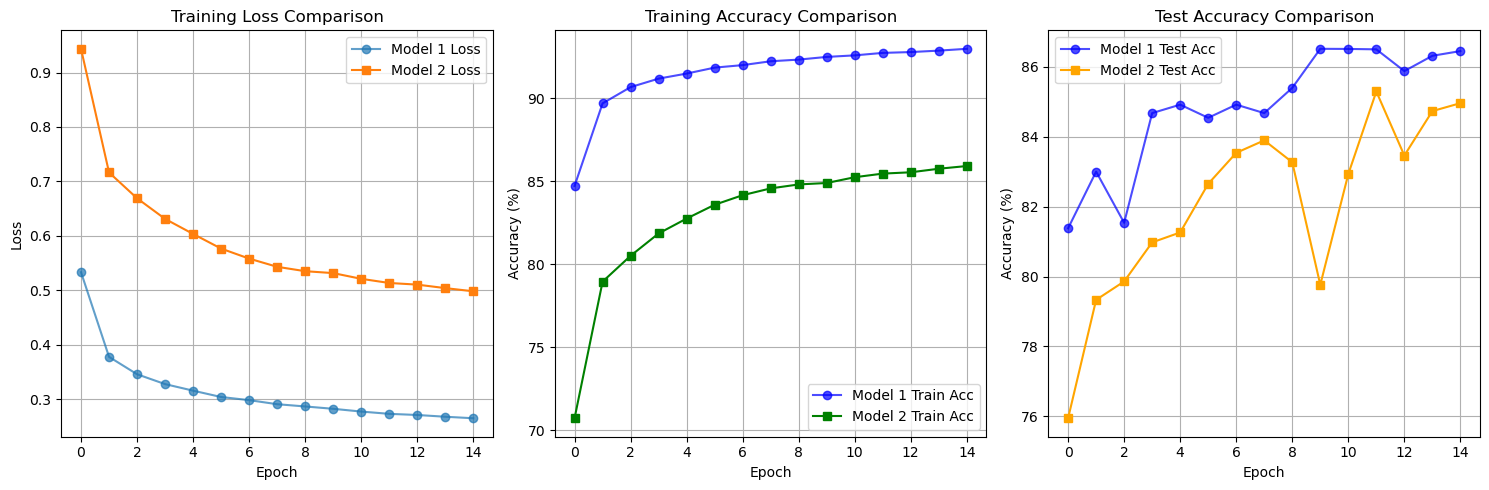

,Model,Modifications,Epochs,Final Train Accuracy,Final Test Accuracy,Train-Test Gap,Improvement,Notes
0,Baseline MLP (Model 1),None (baseline),15,92.97%,86.45%,6.52%,-,Used extra data
1,Improved MLP (Model 2),Deeper network + LeakyReLU + Dropout,15,85.91%,84.96%,0.95%,+-1.49%,Two improvements required by assignment


In [9]:
# ==================== 画曲线 ====================
plt.figure(figsize=(15, 5))  # Slightly wider to accommodate more plots

plt.subplot(1, 3, 1)  # Changed to 1x3 grid
plt.plot(train_loss_list, label='Model 1 Loss', marker='o', alpha=0.7)
plt.plot(train_loss_list2, label='Model 2 Loss', marker='s')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)  # New subplot for Train Accuracy
plt.plot(train_acc_list, label='Model 1 Train Acc', marker='o', alpha=0.7, color='blue')
plt.plot(train_acc_list2, label='Model 2 Train Acc', marker='s', color='green')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)  # Changed to third subplot
plt.plot(test_acc_list, label='Model 1 Test Acc', marker='o', alpha=0.7, color='blue')
plt.plot(test_acc_list2, label='Model 2 Test Acc', marker='s', color='orange')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ==================== Comparison Table ====================
import pandas as pd
results = pd.DataFrame({
    'Model': ['Baseline MLP (Model 1)', 'Improved MLP (Model 2)'],
    'Modifications': ['None (baseline)', 'Deeper network + LeakyReLU + Dropout'],
    'Epochs': [15, 15],
    'Final Train Accuracy': [f"{train_acc_list[-1]:.2f}%", f"{train_acc_list2[-1]:.2f}%"],  # Added
    'Final Test Accuracy': [f"{test_acc_list[-1]:.2f}%", f"{test_acc_list2[-1]:.2f}%"],
    'Train-Test Gap': [
        f"{train_acc_list[-1] - test_acc_list[-1]:.2f}%",  # Model 1 gap
        f"{train_acc_list2[-1] - test_acc_list2[-1]:.2f}%"  # Model 2 gap
    ],
    'Improvement': ['-', f'+{test_acc_list2[-1] - test_acc_list[-1]:.2f}%'],
    'Notes': ['Used extra data', 'Two improvements required by assignment']
})
display(results)

# Model 3: CNN

##  CNN Defination

In [11]:
class SVHNCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model3 = SVHNCNN().to(device)
print(f"Model 3 CNN:  The Parameters' Number: {sum(p.numel() for p in model3.parameters()):,}")

Model 3 CNN:  The Parameters' Number: 1,147,914


## Model 3: Training(epochs: 15)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.001)

train_loss_list3 = []
train_acc_list3 = []  # Added for train accuracy
test_acc_list3 = []
epochs = 15

print("开始训练 Model 3 CNN...")

for epoch in range(epochs):
    # Train
    model3.train()
    running_loss = 0.0
    correct_train = 0  # Added
    total_train = 0    # Added
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train  # Added
    
    train_loss_list3.append(avg_train_loss)
    train_acc_list3.append(train_acc)  # Store train accuracy
    
    # Test
    model3.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model3(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_acc = 100 * correct / total
    test_acc_list3.append(test_acc)
    
    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")  # Updated print

print("Model 3 训练完成！")

开始训练 Model 3 CNN...


Epoch 1/15: 100%|██████████| 4722/4722 [00:56<00:00, 83.11it/s]


Epoch  1 | Train Loss: 0.3507 | Train Acc: 89.35% | Test Acc: 93.42%


Epoch 2/15: 100%|██████████| 4722/4722 [00:56<00:00, 82.96it/s]


Epoch  2 | Train Loss: 0.1806 | Train Acc: 95.01% | Test Acc: 94.61%


...

Epoch 13 | Train Loss: 0.0545 | Train Acc: 98.51% | Test Acc: 96.17%


Epoch 14/15: 100%|██████████| 4722/4722 [00:56<00:00, 82.90it/s]


Epoch 14 | Train Loss: 0.0507 | Train Acc: 98.60% | Test Acc: 96.12%


Epoch 15/15: 100%|██████████| 4722/4722 [00:56<00:00, 83.07it/s]


Epoch 15 | Train Loss: 0.0482 | Train Acc: 98.65% | Test Acc: 96.06%
Model 3 训练完成！


# Three models comparison

✅ Complete models saved
✅ Model weights saved
✅ Training history saved to saved_models
✅ Training history loaded successfully! (Saved on: 2026-03-19 08:34:01)


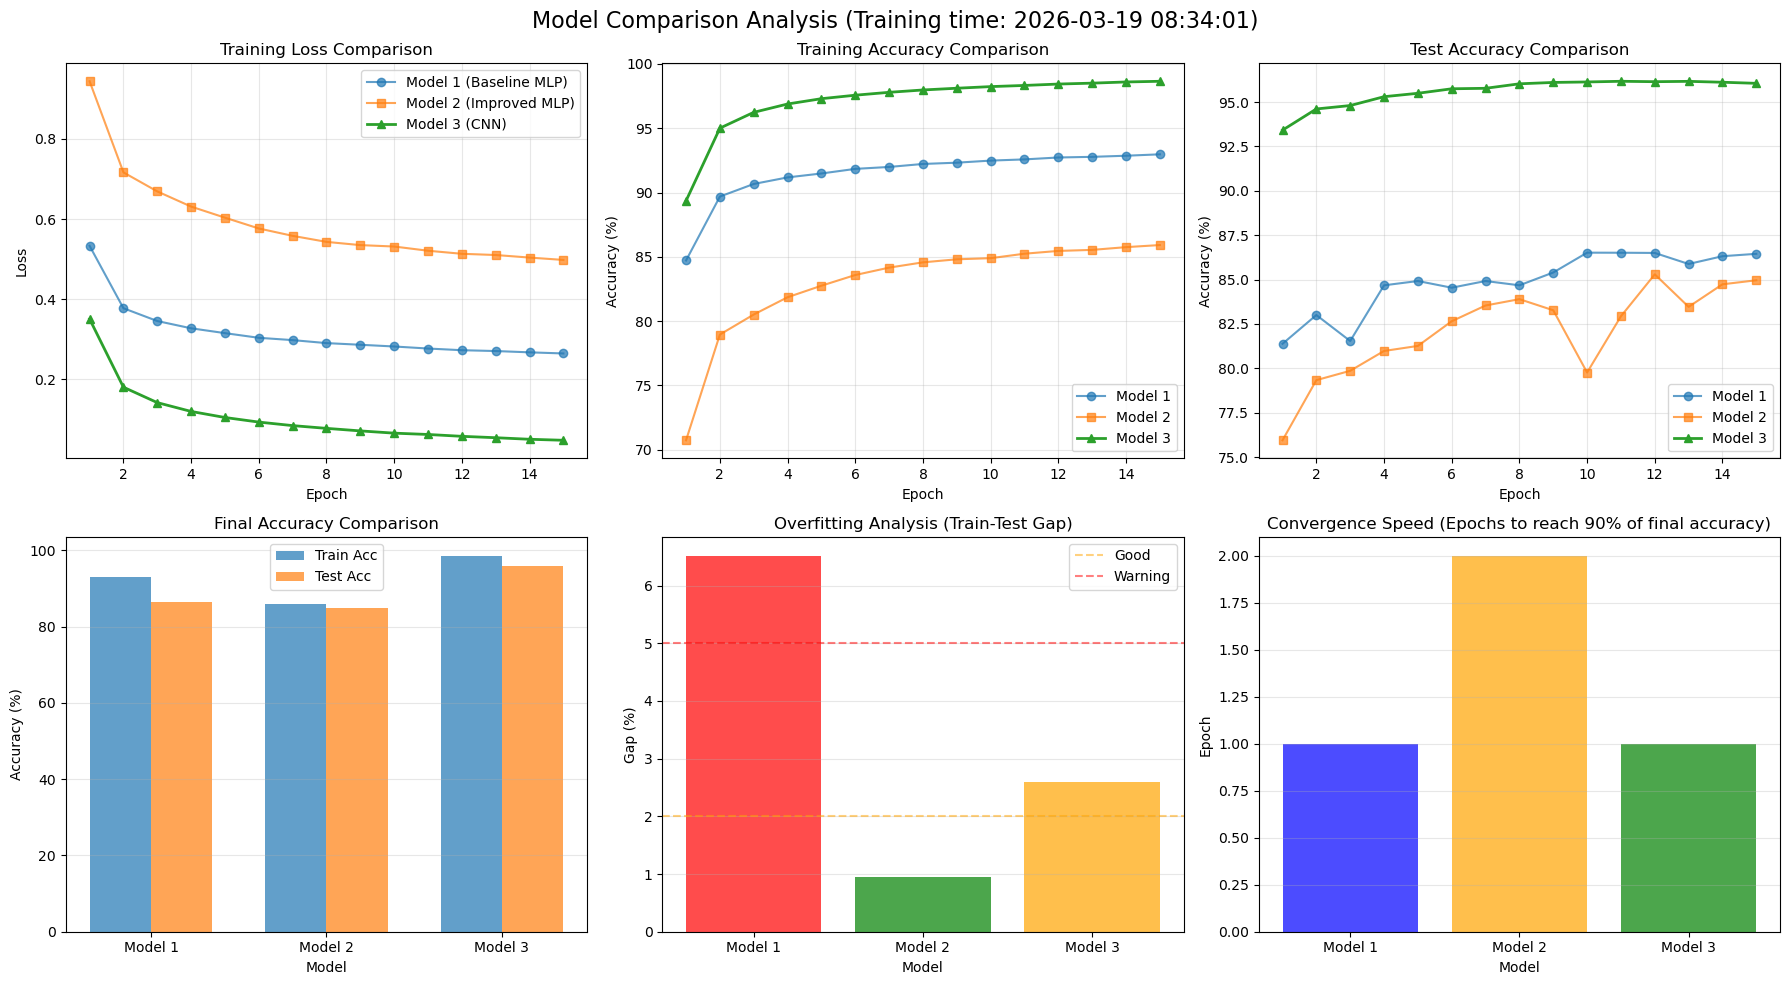

,Model,Final Train Acc,Final Test Acc,Train-Test Gap,Convergence Epoch
0,Baseline MLP,92.97%,86.45%,6.52%,1
1,Improved MLP,85.91%,84.96%,0.95%,2
2,CNN,98.65%,96.06%,2.59%,1


In [13]:
import torch
import os
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# ==================== Setup Save Directory ====================
SAVE_DIR = Path('saved_models')
SAVE_DIR.mkdir(exist_ok=True)

# ==================== Save Function After Training ====================
def save_all_models(model1, model2, model3, 
                   train_loss_list, train_loss_list2, train_loss_list3,
                   train_acc_list, train_acc_list2, train_acc_list3,
                   test_acc_list, test_acc_list2, test_acc_list3,
                   epochs=15):
    
    # 1. Save entire models (for direct later use)
    torch.save(model1, SAVE_DIR / 'model1_complete.pth')
    torch.save(model2, SAVE_DIR / 'model2_complete.pth')
    torch.save(model3, SAVE_DIR / 'model3_complete.pth')
    print("✅ Complete models saved")
    
    # 2. Save model parameters (for loading into same architecture)
    torch.save(model1.state_dict(), SAVE_DIR / 'model1_weights.pth')
    torch.save(model2.state_dict(), SAVE_DIR / 'model2_weights.pth')
    torch.save(model3.state_dict(), SAVE_DIR / 'model3_weights.pth')
    print("✅ Model weights saved")
    
    # 3. Save training history data (for visualization comparison)
    training_history = {
        'model1': {
            'train_loss': train_loss_list,
            'train_acc': train_acc_list,
            'test_acc': test_acc_list
        },
        'model2': {
            'train_loss': train_loss_list2,
            'train_acc': train_acc_list2,
            'test_acc': test_acc_list2
        },
        'model3': {
            'train_loss': train_loss_list3,
            'train_acc': train_acc_list3,
            'test_acc': test_acc_list3
        },
        'metadata': {
            'epochs': epochs,
            'saved_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        }
    }
    
    # Save as pickle file (easy to load)
    with open(SAVE_DIR / 'training_history.pkl', 'wb') as f:
        pickle.dump(training_history, f)
    
    # Also save as CSV format (easy to view)
    history_df = pd.DataFrame({
        'Epoch': range(1, epochs+1),
        'Model1_Loss': train_loss_list,
        'Model1_TrainAcc': train_acc_list,
        'Model1_TestAcc': test_acc_list,
        'Model2_Loss': train_loss_list2,
        'Model2_TrainAcc': train_acc_list2,
        'Model2_TestAcc': test_acc_list2,
        'Model3_Loss': train_loss_list3,
        'Model3_TrainAcc': train_acc_list3,
        'Model3_TestAcc': test_acc_list3
    })
    history_df.to_csv(SAVE_DIR / 'training_history.csv', index=False)
    
    print(f"✅ Training history saved to {SAVE_DIR}")
    return training_history

# ==================== Loading Functions ====================
def load_training_history():
    """Load training history for visualization"""
    history_path = SAVE_DIR / 'training_history.pkl'
    if history_path.exists():
        with open(history_path, 'rb') as f:
            history = pickle.load(f)
        print(f"✅ Training history loaded successfully! (Saved on: {history['metadata']['saved_date']})")
        return history
    else:
        print("❌ Training history file not found")
        return None

def load_model_weights(model_class, model_name, device='cuda'):
    """Load model weights into specified model architecture"""
    weights_path = SAVE_DIR / f'{model_name}_weights.pth'
    if weights_path.exists():
        model = model_class().to(device)
        model.load_state_dict(torch.load(weights_path, map_location=device))
        model.eval()
        print(f"✅ {model_name} weights loaded successfully")
        return model
    else:
        print(f"❌ Weights file for {model_name} not found")
        return None

# ==================== Visualization Comparison Function ====================
def plot_model_comparison_from_saved():
    """Plot comparison charts from saved history data"""
    
    # Load history data
    history = load_training_history()
    if history is None:
        return
    
    # Extract data
    m1 = history['model1']
    m2 = history['model2']
    m3 = history['model3']
    epochs = history['metadata']['epochs']
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Model Comparison Analysis (Training time: {history["metadata"]["saved_date"]})', fontsize=16)
    
    # 1. Training Loss Comparison
    ax = axes[0, 0]
    ax.plot(range(1, epochs+1), m1['train_loss'], 'o-', label='Model 1 (Baseline MLP)', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_loss'], 's-', label='Model 2 (Improved MLP)', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_loss'], '^-', label='Model 3 (CNN)', linewidth=2)
    ax.set_title('Training Loss Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Training Accuracy Comparison
    ax = axes[0, 1]
    ax.plot(range(1, epochs+1), m1['train_acc'], 'o-', label='Model 1', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_acc'], 's-', label='Model 2', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_acc'], '^-', label='Model 3', linewidth=2)
    ax.set_title('Training Accuracy Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Test Accuracy Comparison
    ax = axes[0, 2]
    ax.plot(range(1, epochs+1), m1['test_acc'], 'o-', label='Model 1', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['test_acc'], 's-', label='Model 2', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['test_acc'], '^-', label='Model 3', linewidth=2)
    ax.set_title('Test Accuracy Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Final Accuracy Bar Chart
    ax = axes[1, 0]
    models = ['Model 1', 'Model 2', 'Model 3']
    train_acc_final = [m1['train_acc'][-1], m2['train_acc'][-1], m3['train_acc'][-1]]
    test_acc_final = [m1['test_acc'][-1], m2['test_acc'][-1], m3['test_acc'][-1]]
    
    x = range(len(models))
    width = 0.35
    ax.bar([i - width/2 for i in x], train_acc_final, width, label='Train Acc', alpha=0.7)
    ax.bar([i + width/2 for i in x], test_acc_final, width, label='Test Acc', alpha=0.7)
    ax.set_title('Final Accuracy Comparison')
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. Overfitting Analysis (Train-Test Gap)
    ax = axes[1, 1]
    gaps = [m1['train_acc'][-1] - m1['test_acc'][-1],
            m2['train_acc'][-1] - m2['test_acc'][-1],
            m3['train_acc'][-1] - m3['test_acc'][-1]]
    
    colors = ['red' if g > 5 else 'orange' if g > 2 else 'green' for g in gaps]
    bars = ax.bar(models, gaps, color=colors, alpha=0.7)
    ax.set_title('Overfitting Analysis (Train-Test Gap)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Gap (%)')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='Good')
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Warning')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. Convergence Speed Analysis
    ax = axes[1, 2]
    # Calculate epoch reaching 90% of final test accuracy
    def convergence_epoch(acc_list, threshold=0.9):
        final_acc = acc_list[-1]
        target = final_acc * threshold
        for i, acc in enumerate(acc_list):
            if acc >= target:
                return i + 1
        return epochs
    
    conv_epochs = [
        convergence_epoch(m1['test_acc']),
        convergence_epoch(m2['test_acc']),
        convergence_epoch(m3['test_acc'])
    ]
    
    ax.bar(models, conv_epochs, color=['blue', 'orange', 'green'], alpha=0.7)
    ax.set_title('Convergence Speed (Epochs to reach 90% of final accuracy)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Epoch')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Display summary table
    summary_df = pd.DataFrame({
        'Model': ['Baseline MLP', 'Improved MLP', 'CNN'],
        'Final Train Acc': [f"{m1['train_acc'][-1]:.2f}%", 
                           f"{m2['train_acc'][-1]:.2f}%", 
                           f"{m3['train_acc'][-1]:.2f}%"],
        'Final Test Acc': [f"{m1['test_acc'][-1]:.2f}%", 
                          f"{m2['test_acc'][-1]:.2f}%", 
                          f"{m3['test_acc'][-1]:.2f}%"],
        'Train-Test Gap': [f"{m1['train_acc'][-1] - m1['test_acc'][-1]:.2f}%",
                          f"{m2['train_acc'][-1] - m2['test_acc'][-1]:.2f}%",
                          f"{m3['train_acc'][-1] - m3['test_acc'][-1]:.2f}%"],
        'Convergence Epoch': conv_epochs
    })
    
    return summary_df

# ==================== Usage Examples ====================

# Save all models and data after training
save_all_models(
    model1, model2, model3,
    train_loss_list, train_loss_list2, train_loss_list3,
    train_acc_list, train_acc_list2, train_acc_list3,
    test_acc_list, test_acc_list2, test_acc_list3,
    epochs=15
)

# Next time, directly load history data for visualization
summary = plot_model_comparison_from_saved()
display(summary)

# If you need to load specific model weights
# from your_model_definitions import ImprovedMLP, CNN  # Import your model classes
# model2 = load_model_weights(ImprovedMLP, 'model2', device)
# model3 = load_model_weights(CNN, 'model3', device)